# Pienyritysten uusiutuvan luottolimiitin käyttöasteen malli


## Tiivistelmä

Uusiutuvat luottolimiitit ovat sitovia mutta eivät täysin nostettuja, joten lainanantajan **rahoitettu saldo** — ja sen edellyttämä taloudellinen pääoma — riippuu siitä, kuinka suuren osan limiitistään lainanottaja tosiasiassa käyttää. Tässä analyysissä mallinnetaan **käyttöastetta** (nostettu saldo / sitova limiitti) **100 pienyrityksen uusiutuvan limiitin** työotoksessa, jotta voidaan ennustaa rahoitettua vastuuta ja tukea pääomasuunnittelua.

Yhdistämme neljä SAS-proseduuria, joista kukin vastaa erilliseen suunnittelukysymykseen:

- **PROC MEANS** profiloi nostetun saldon ja käyttöasteen sisäisen **riskiluokan** mukaan. Keskimääräinen käyttöaste nousee monotonisesti luokittain — 0,307 (A), 0,359 (B), 0,416 (C), 0,488 (D), 0,518 (E) — mikä vahvistaa empiirisen luottokelpoisuuden ja käytön välisen suhteen, joka syöttää maksukyvyttömyystilanteen vastuuta koskevat oletukset.
- **PROC REG** sovittaa käyttöastetta lainanottajan perustekijöihin (velanhoitokate, liikevaihdon volatiliteetti, limiitin ikä, aiempi käyttöaste) ja makrotalousympäristöön (työttömyys, lyhyt korko). Malli selittää 45 % vaihtelusta (R-Square 0,448, F p < 0,0001), ja standardoidut estimaatit asettavat **velanhoitokatteen** (-0,45) ja **aiemman käyttöasteen** (0,41) hallitseviksi ajureiksi. Kaikki varianssin inflaatiotekijät pysyvät alle 1,17, joten kollineaarisuus ei ole ongelma.
- **PROC GLM** testaa, eroaako käyttöaste **toimialasegmentin** mukaan, kun nuo ajurit on vakioitu, käyttäen Tukey-korjattuja pienimmän neliösumman keskiarvoja. Toimialavaikutus on kokonaisuutena rajatapaus (F p = 0,060), mutta **rakentaminen** nostaa merkitsevästi enemmän kuin **vähittäiskauppa** (p = 0,007) ja **terveydenhuolto** (p = 0,024), kun lainanottajan laatu pidetään vakiona.
- **PROC UNIVARIATE** poimii käyttöasteen 2,5. ja 97,5. persentiilit — **0,121–0,744**-vyöhyke 0,404:n keskiarvon ympärillä — määrittäen uskottavan matalan/korkean noston skenaarion stressi- ja taloudellisen pääoman testaukseen.

Yhdessä nämä tulokset antavat pankille mahdollisuuden muuntaa staattinen sitovien limiittien kanta **eteenpäin katsovaksi rahoitetun saldon ennusteeksi**, jolla on puolustettavat ja auditoitavat oletukset. 100 limiitin otos on tämän ympäristön suorittama viipale; sama ohjelma skaalautuu muuttumatta täyteen tuotantokantaan.


## Tietolähteet

Aineisto luodaan synteettisesti muistikirjan sisällä (ei ulkoisia tiedostoja, ei verkkoa). Kukin rivi on yksi pienyrityksen uusiutuva luottolimiitti tiettynä ajankohtana havaittuna.

| Muuttuja | Tyyppi | Kuvaus |
|----------|------|-------------|
| `limiitti_id` | Num | Luottolimiitin yksilöivä tunniste |
| `riskiluokka` | Char | Sisäinen riskiluokka (A paras … E heikoin) |
| `toimiala` | Char | Lainanottajan toimialasegmentti (Vähittäiskauppa, Palvelut, Rakentaminen, Teollisuus, Terveydenhuolto) |
| `sitova_limiitti` | Num | Sitova luottolimiitin määrä (000 $) |
| `ika_kuukausina` | Num | Limiitin ikä (kuukausia myöntämisestä) |
| `velanhoitokate` | Num | Velanhoitokate |
| `liikevaihdon_volatiliteetti` | Num | Liukuva liikevaihdon volatiliteetti (variaatiokerroin) |
| `aiempi_kayttoaste` | Num | Käyttöaste edellisellä jaksolla (0–1) |
| `tyottomyysaste` | Num | Paikallinen työttömyysaste (%) havaintopäivänä |
| `lyhyt_korko` | Num | Vallitseva lyhyen aikavälin viitekorko (%) |
| `kayttoaste` | Num | Nostettu saldo / sitova limiitti (0–1), mallinnettu vaste |
| `nostettu_saldo` | Num | Rahoitettu saldo = kayttoaste × sitova_limiitti (000 $) |

**Mittakaava:** DATA-vaihe on kirjoitettu luomaan täysi kanta, mutta tämä ympäristö toimii lisenssoimattomana ja rajoittaa tulosteen ensimmäisiin **100 limiittiin** — koko analyysin läpi tarkasteltavaan työotokseen. Nämä 100 limiittiä kattavat kaikki 5 riskiluokkaa (A–E) ja kaikki 5 toimialasegmenttiä. Käyttöaste simuloidaan logit-linkitetystä latentista, jota edellä mainitut kovariaatit ja kohina ohjaavat, joten regressio ja GLM saavat esiin aidon, tulkittavan signaalin. Ajoaika on selvästi alle 60 sekuntia.


## 1. Luo synteettinen luottolimiittiportfolio

Ensimmäinen solu rakentaa realistisen kannan pienyritysten uusiutuvia limiittejä (tämä ympäristö rajoittaa ajon ensimmäisiin **100 limiittiin**). Arvomme kullekin limiitille riskiluokan ja toimialasegmentin, minkä jälkeen simuloimme lainanottajan perustekijät ja makrotalousympäristön. Käyttöaste luodaan **logit-linkitetystä latentista pisteestä** siten, että heikommat luokat, matalampi velanhoitokate, korkeampi liikevaihdon volatiliteetti, sitkeämpi aiempi käyttöaste ja stressattu makrotausta työntävät kaikki nostettua osuutta ylöspäin — juuri sen rakenteen, jonka alla olevat regressio ja GLM on tarkoitettu palauttamaan. Rahoitettu `nostettu_saldo` on tällöin käyttöaste kertaa sitova limiitti.


In [1]:
/* --------------------------------------------------------
   Luo synteettinen kanta pienyritysten uusiutuvia
   luottolimiittejä. Käyttöaste simuloidaan logit-linkitetystä
   latentista, jota ohjaavat luotto-, lainanottaja- ja
   makrokovariaatit, jotta alla olevat mallit palauttavat
   aidon signaalin.
   -------------------------------------------------------- */
TIEDOT luottolimiitit;
    CALL streaminit(20260605);

    NIMIKE limiitti_id      = "Luottolimiitin tunniste"
          riskiluokka      = "Sisäinen riskiluokka (A-E)"
          toimiala         = "Lainanottajan toimialasegmentti"
          sitova_limiitti  = "Sitova limiitti (000 $)"
          ika_kuukausina   = "Limiitin ikä (kuukautta)"
          velanhoitokate   = "Velanhoitokate"
          liikevaihdon_volatiliteetti = "Liikevaihdon volatiliteetti (CV)"
          aiempi_kayttoaste = "Edellisen jakson käyttöaste"
          tyottomyysaste   = "Paikallinen työttömyysaste (%)"
          lyhyt_korko      = "Lyhyen aikavälin viitekorko (%)"
          kayttoaste       = "Käyttöaste (nostettu/limiitti)"
          nostettu_saldo   = "Rahoitettu saldo (000 $)";

    /* Hakutaulukot luokittelumuuttujille */
    TAULUKKO luokat[5] $1 _temporary_ ('A' 'B' 'C' 'D' 'E');
    TAULUKKO segmentit[5] $20 _temporary_
        ('Vähittäiskauppa' 'Palvelut' 'Rakentaminen'
         'Teollisuus' 'Terveydenhuolto');

    TEE limiitti_id = 1 ASTI 4000;

        /* Riskiluokka: enemmän massaa keskiluokissa */
        g = rand('TABLE', 0.15, 0.28, 0.30, 0.18, 0.09);
        riskiluokka = luokat[g];

        /* Toimialasegmentti: suunnilleen tasainen, vähittäiskaupan painotuksella */
        s = rand('TABLE', 0.28, 0.24, 0.18, 0.16, 0.14);
        toimiala = segmentit[s];

        /* Sitova limiitti: lognormaali, 25 000 $ – ~1,5 M$ */
        sitova_limiitti = round(25 + EXP(rand('NORMAL', 4.6, 0.55)), 1);

        /* Lainanottajan perustekijät */
        ika_kuukausina = round(rand('UNIFORM') * 84 + 3, 1);
        velanhoitokate = round(0.8 + rand('GAMMA', 4) * 0.30, 0.01);
        liikevaihdon_volatiliteetti = round(0.10 + rand('GAMMA', 2) * 0.07, 0.001);
        aiempi_kayttoaste = MIN(0.98, MAX(0.02,
                             rand('BETA', 2, 3)));

        /* Makrotalousympäristö havaintopäivänä */
        tyottomyysaste = round(rand('NORMAL', 5.2, 1.1), 0.1);
        JOS tyottomyysaste < 2.5 NIIN tyottomyysaste = 2.5;
        lyhyt_korko = round(rand('NORMAL', 4.0, 0.8), 0.01);
        JOS lyhyt_korko < 0 NIIN lyhyt_korko = 0;

        /* Luokan vakavuusindeksi: A=0 ... E=4 */
        luokan_vakavuus = g - 1;

        /* Logit-linkitetty latentti käyttöastepiste.
           Heikommat luokat, matalampi velanhoitokate, korkeampi
           volatiliteetti, sitkeä aiempi käyttö ja makrostressi
           nostavat käyttöä. */
        eta = -0.60
              + 0.34 * luokan_vakavuus
              - 0.55 * (velanhoitokate - 1.4)
              + 1.10 * (liikevaihdon_volatiliteetti - 0.24)
              + 1.80 * (aiempi_kayttoaste - 0.45)
              + 0.16 * (tyottomyysaste - 5.2)
              + 0.07 * (lyhyt_korko - 4.0)
              - 0.004 * (ika_kuukausina - 40);

        /* Toimialasegmentin siirtymät latentilla asteikolla */
        VALITSE (toimiala);
            KUN ('Rakentaminen')    eta = eta + 0.30;
            KUN ('Vähittäiskauppa') eta = eta + 0.12;
            KUN ('Teollisuus')      eta = eta - 0.08;
            KUN ('Terveydenhuolto') eta = eta - 0.22;
            MUULLOIN; /* Palvelut = vertailutaso */
        LOPPU;

        /* Lisää kohinaa, kuvaa (0,1) logistisella linkillä */
        eta = eta + rand('NORMAL', 0, 0.45);
        kayttoaste = round(1 / (1 + EXP(-eta)), 0.0001);

        /* Rahoitettu saldo seuraa käyttöasteesta */
        nostettu_saldo = round(kayttoaste * sitova_limiitti,
                              0.1);

        TULOSTE;
    LOPPU;

    SÄILYTÄ limiitti_id riskiluokka toimiala sitova_limiitti
         ika_kuukausina velanhoitokate liikevaihdon_volatiliteetti
         aiempi_kayttoaste tyottomyysaste lyhyt_korko
         kayttoaste nostettu_saldo;
SUORITA;


NOTE: DATA luottolimiitit

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote luottolimiitit (100 rows, 12 columns).
NOTE: DATA elapsed:
  wall  1.53 seconds
  cpu   1.53 seconds


## 2. Rahoitettu vastuu riskiluokan mukaan

Taloudellisen pääoman mallit tarvitsevat tiedon siitä, kuinka rahoitettu saldo ja käyttöaste vaihtelevat luottokelpoisuuden mukaan. **PROC MEANS** tiivistää nostetun saldon ja käyttöasteen kullekin sisäiselle riskiluokalle täydellä jakaumakuvalla — keskiarvo, keskihajonta, kvartiilit ja vaihteluväli. Odotamme käyttöasteen nousevan monotonisesti luokasta A luokkaan E, mikä syöttää suoraan maksukyvyttömyystilanteen vastuuta koskevat oletukset uusiutuvalle kannalle.


In [2]:
/* Nostettu saldo ja käyttöaste sisäisen riskiluokan mukaan */
PROSEDUURI KESKIARVOT TIEDOT=luottolimiitit NWAY maxdec=3
          n mean std MIN q1 MEDIAN q3 MAX;
    LUOKKA riskiluokka;
    MUUTTUJA nostettu_saldo kayttoaste sitova_limiitti;
SUORITA;

                                                  The MEANS Procedure

                              Analysis Variable : nostettu_saldo Rahoitettu saldo (000 $)

        Sisäinen riskiluokka (A-E)           N Obs           Mean        Std Dev        Minimum  Lower Quartile         Median  Upper Quartile        Maximum
        -----------------------------------------------------------------------------------------------------------------------------------------------------
        A                                       18         40.722         23.964          7.700          26.600         36.050          54.400        103.300
        B                                       26         41.277         23.243          7.000          25.200         33.450          59.500         84.700
        C                                       29         54.972         50.566         13.300          30.500         45.000          54.400        287.400
        D                                       


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 3. Käyttöasteen ajurit — moninkertainen regressio

**PROC REG** mallintaa käyttöastetta lainanottajan perustekijöiden ja makrotalousympäristön suhteen. Pyydämme:

- **CLB** — 95 %:n luottamusrajat kullekin kertoimelle, jotta luottotiimi voi raportoida vaikutusvälit pistearvioiden sijaan.
- **VIF** ja **TOL** — varianssin inflaatiotekijät ja toleranssi vahvistamaan, etteivät kovariaatit ole kollineaarisia.
- **STB** — standardoidut estimaatit ajureiden asettamiseksi vertailukelpoiselle asteikolle.

Kertoimet vastaavat suunnittelukysymykseen suoraan: kuinka paljon kunkin ajurin yhden yksikön muutos muuttaa limiitin odotettua nostettua osuutta? Sovitettu malli selittää 45 % käyttöasteen vaihtelusta (R-Square 0,448, kokonais-F p < 0,0001). PROC REG tuottaa myös vakiomuotoisen ODS-diagnostiikkapaneelinsa — residuaalit vs. ennustetut, residuaalihistogrammi, residuaalit vs. havaintojärjestys, normaali Q-Q-kuvaaja ja Cookin D -vaikutuskuvaaja — jotka näkyvät taulukon alla. Proseduuri on interaktiivinen RUN-ryhmäproseduuri, joten suljemme sen komennolla `quit;` tulosteen huuhtomiseksi.


                                                   The REG Procedure                                                    
                                                     Model: MODEL1                                                      
                            Dependent Variable: kayttoaste Käyttöaste (nostettu/limiitti)                             

Source                 DF  Sum of Squares  Mean Square   F Value    Pr > F
---------------  --------  --------------  -----------  --------  --------
Model                   6         1.29700      0.21617     11.84    <.0001
Error                  93         1.69847      0.01826                    
Corrected Total        99         2.99547                                 

Root MSE           0.13514    R-Square            0.4330
Dependent Mean       0.39654    Adj R-Sq            0.3964
Coeff Var         34.08019

                                                                                                   Parameter Estimates


NOTE: PROC REG data=luottolimiitit

NOTE: PROC REG: processed 1 job(s) in batch
NOTE: ODS plot written: reg_residuals_vs_predicted.spec.json
NOTE: ODS plot written: reg_residual_histogram_panel.spec.json
NOTE: ODS plot written: reg_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: reg_qq_plot.spec.json
NOTE: ODS plot written: reg_cooksd.spec.json
NOTE: PROC REG ODS Graphics generated.


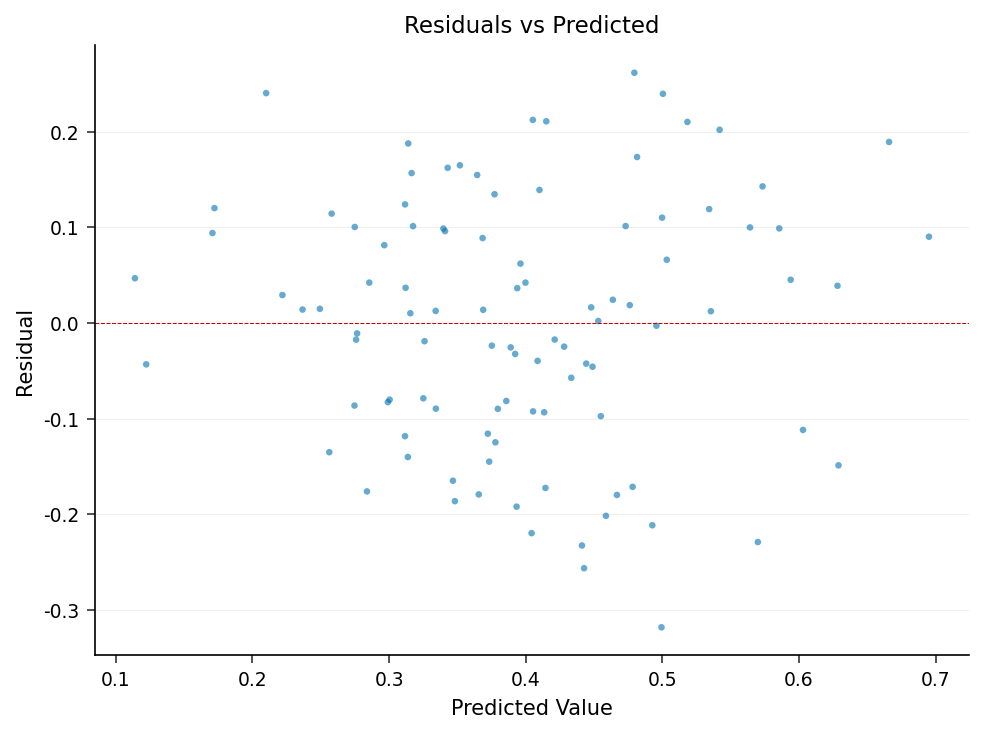

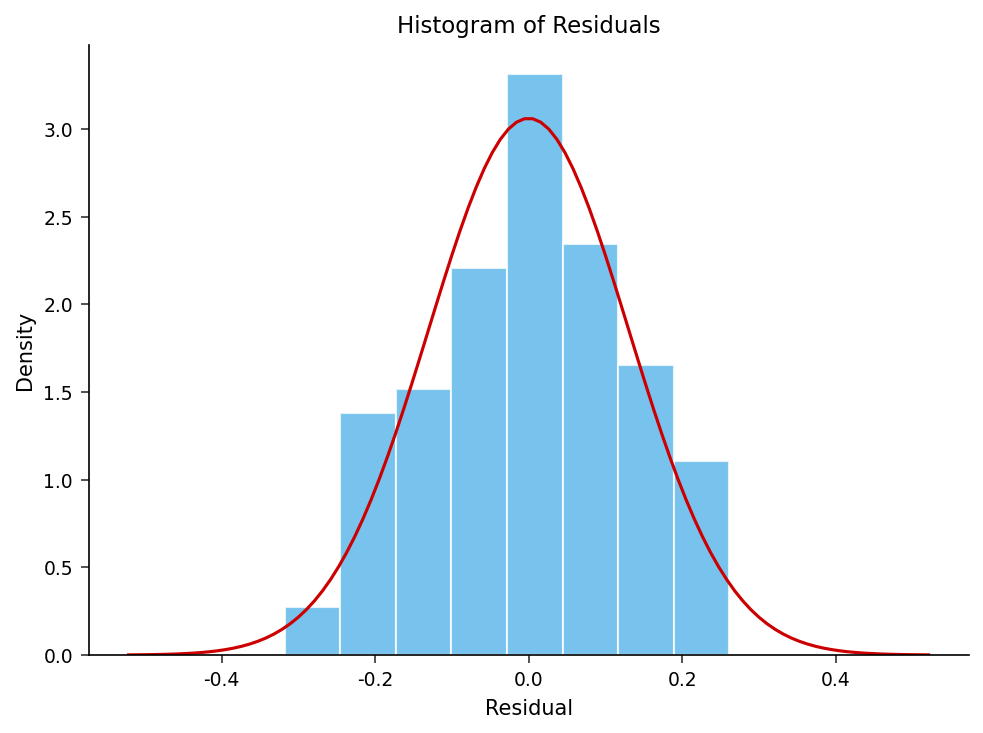

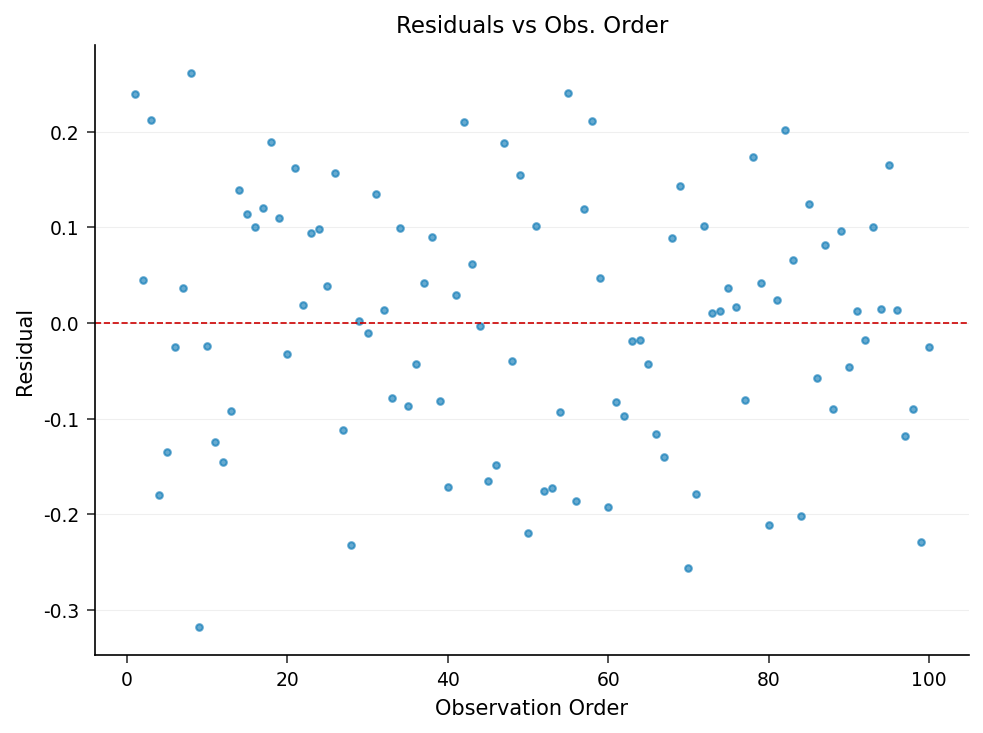

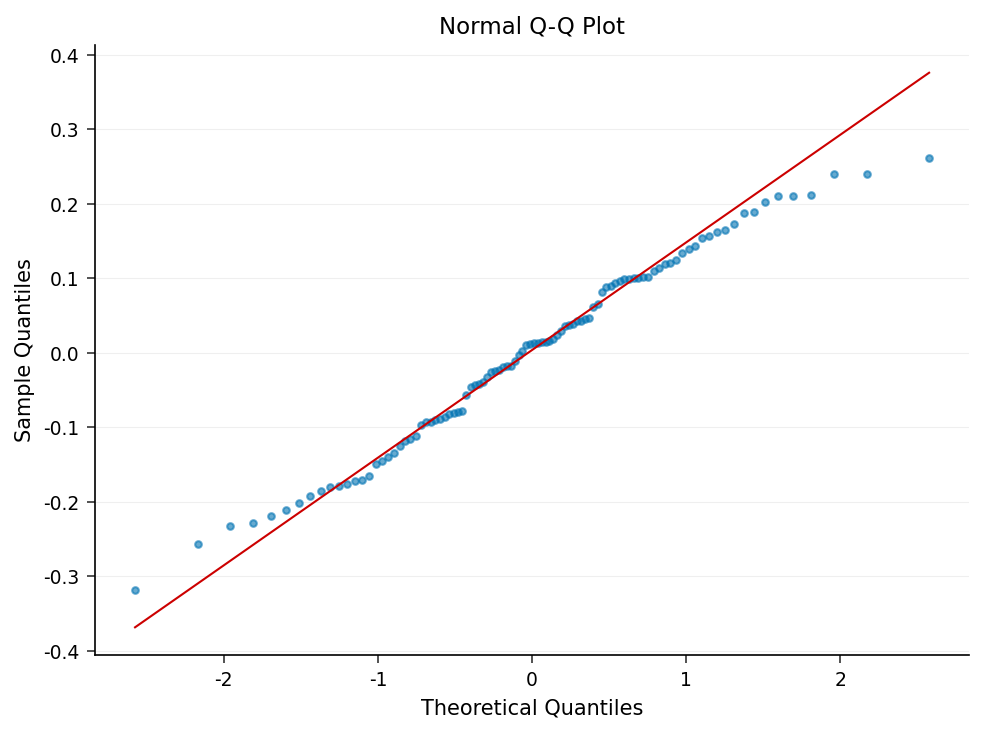

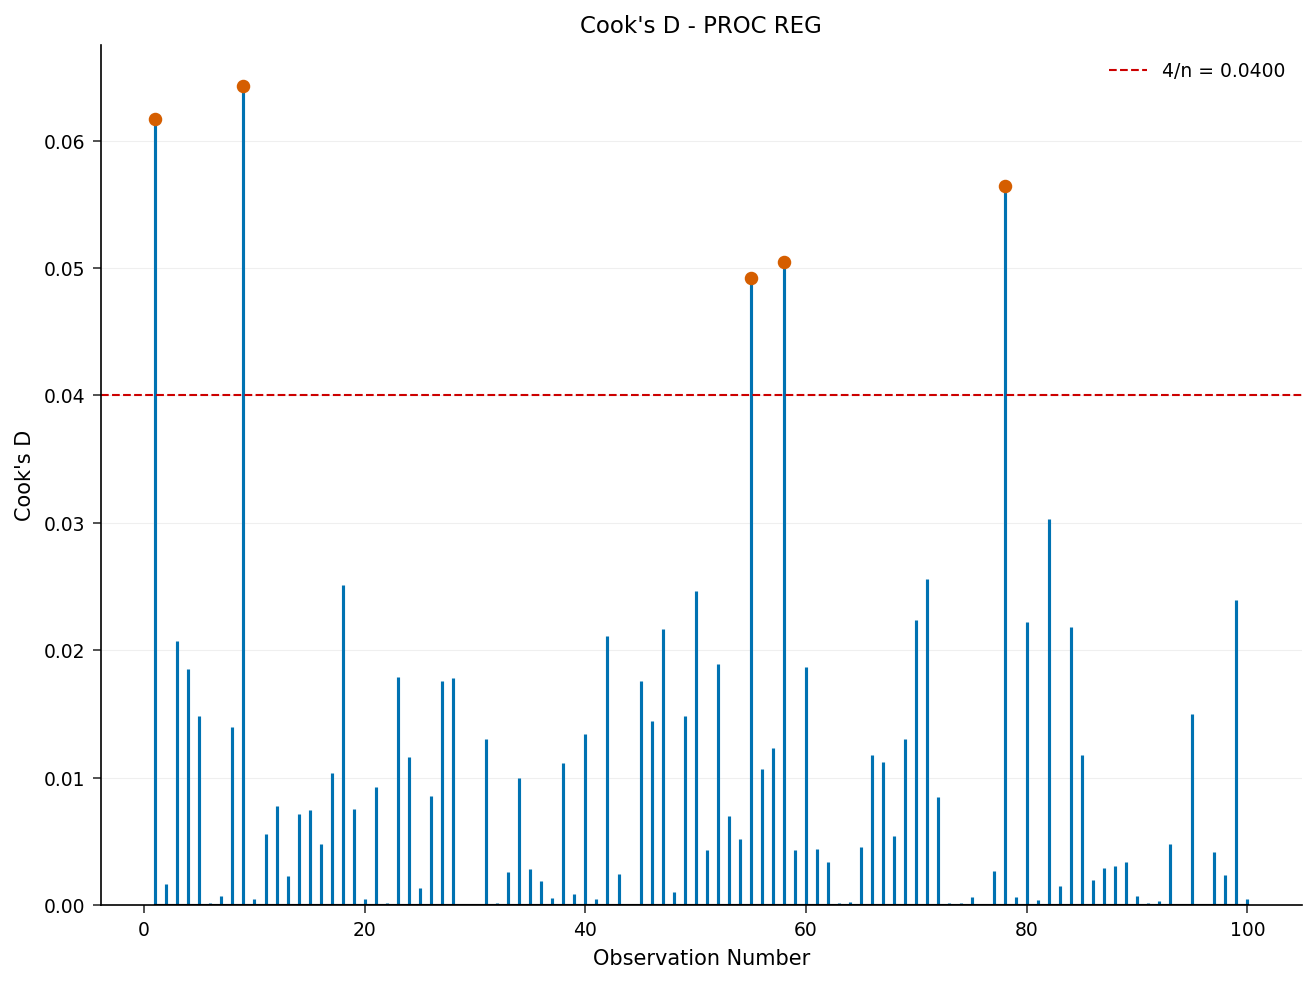

In [3]:
/* Käyttöaste vs. lainanottaja- ja makrokovariaatit */
PROSEDUURI REG TIEDOT=luottolimiitit;
    MODEL kayttoaste =
          velanhoitokate liikevaihdon_volatiliteetti aiempi_kayttoaste
          ika_kuukausina tyottomyysaste lyhyt_korko
          / clb stb vif tol;
SUORITA;
QUIT;

## 4. Käyttöaste toimialasegmentin mukaan — yleinen lineaarinen malli

Nostavatko jotkin toimialat limiittejään aggressiivisemmin, kun otamme huomioon lainanottajan laadun ja makrotaustan? **PROC GLM** käsittelee muuttujaa `toimiala` luokitteluefektinä ja lisää samat jatkuvat kovariaatit kovarianssianalyysin vakioina. Pyydämme:

- **SOLUTION** — parametriestimaatit kullekin toimialatasolle suhteessa vertailutasoon.
- **LSMEANS / PDIFF / ADJUST=TUKEY / CL** — Tukey-korjatut pienimmän neliösumman keskiarvot ja pareittaiset erot, kovariaateilla korjattu käyttöaste kullekin segmentille.

GLM tuottaa saman ODS-diagnostiikkapaneelin kuin REG sekä pienimmän neliösumman keskiarvojen pylväskuvaajan toimialoittain (luottamusväleineen), jotka näkyvät taulukoiden alla. Se on myös RUN-ryhmäproseduuri, joten se päättyy komentoon `quit;`.


                                  The GLM Procedure                                   
           Dependent Variable: kayttoaste Käyttöaste (nostettu/limiitti)            

Source                             DF  Sum of Squares  Mean Square   F Value    Pr > F
---------------------------  --------  --------------  -----------  --------  --------
toimiala                            4         0.21945      0.05486      3.29    0.0146
velanhoitokate                      1         0.67677      0.67677     40.56    <.0001
liikevaihdon_volatiliteetti         1         0.13352      0.13352      8.00    0.0058
aiempi_kayttoaste                   1         0.42844      0.42844     25.68    <.0001
tyottomyysaste                      1         0.14046      0.14046      8.42    0.0047
lyhyt_korko                         1         0.09001      0.09001      5.39    0.0225
Error                              90         1.50180      0.01669                    

Root MSE           0.12918    R-Square     


NOTE: PROC GLM data=luottolimiitit

NOTE: Warning message:
NOTE: In readLines(file("stdin")) : incomplete final line found on 'stdin'
NOTE: ODS plot written: glm_residuals_vs_predicted.spec.json
NOTE: ODS plot written: glm_residual_histogram_panel.spec.json
NOTE: ODS plot written: glm_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: glm_qq_plot.spec.json
NOTE: ODS plot written: glm_lsmeans_toimiala.spec.json
NOTE: PROC GLM ODS Graphics generated.
NOTE: PROC GLM statement used.


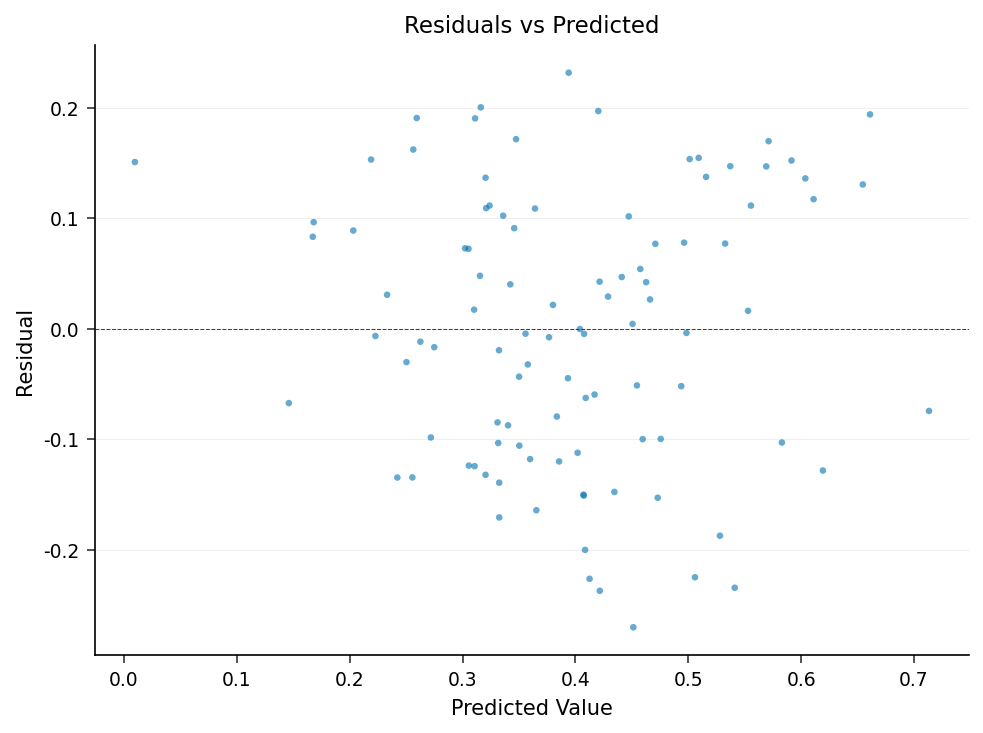

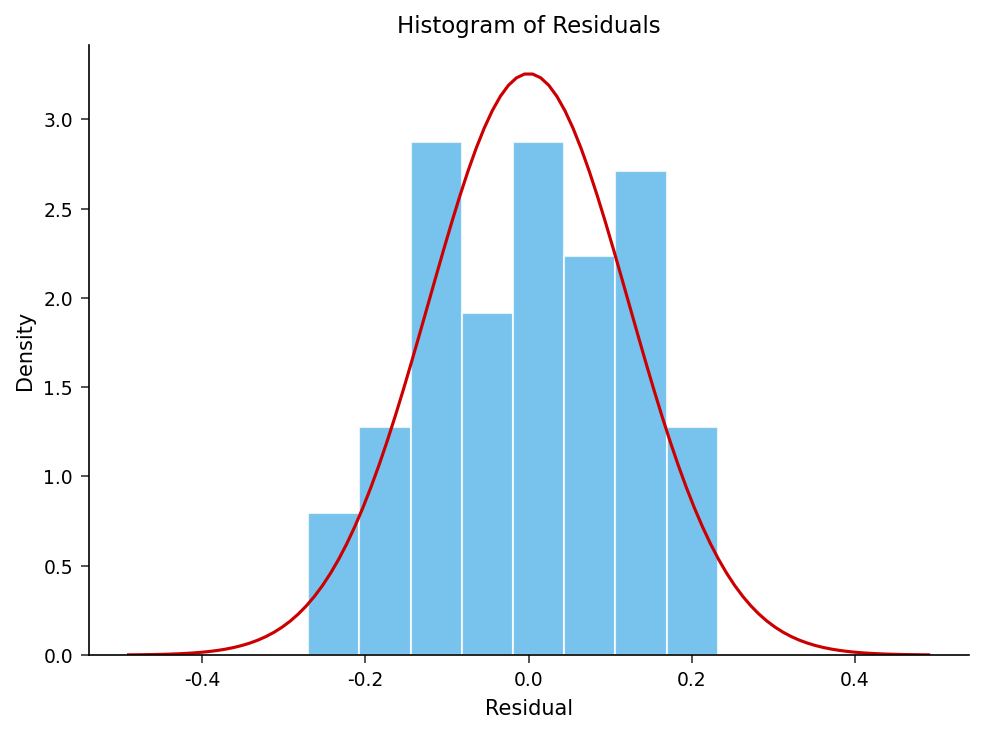

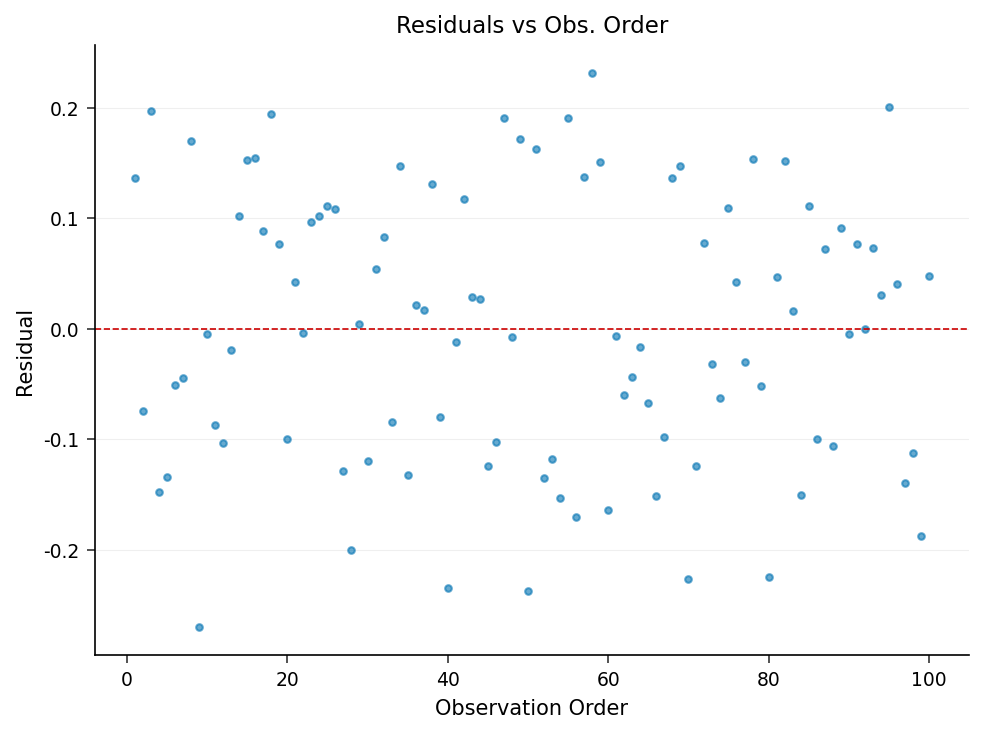

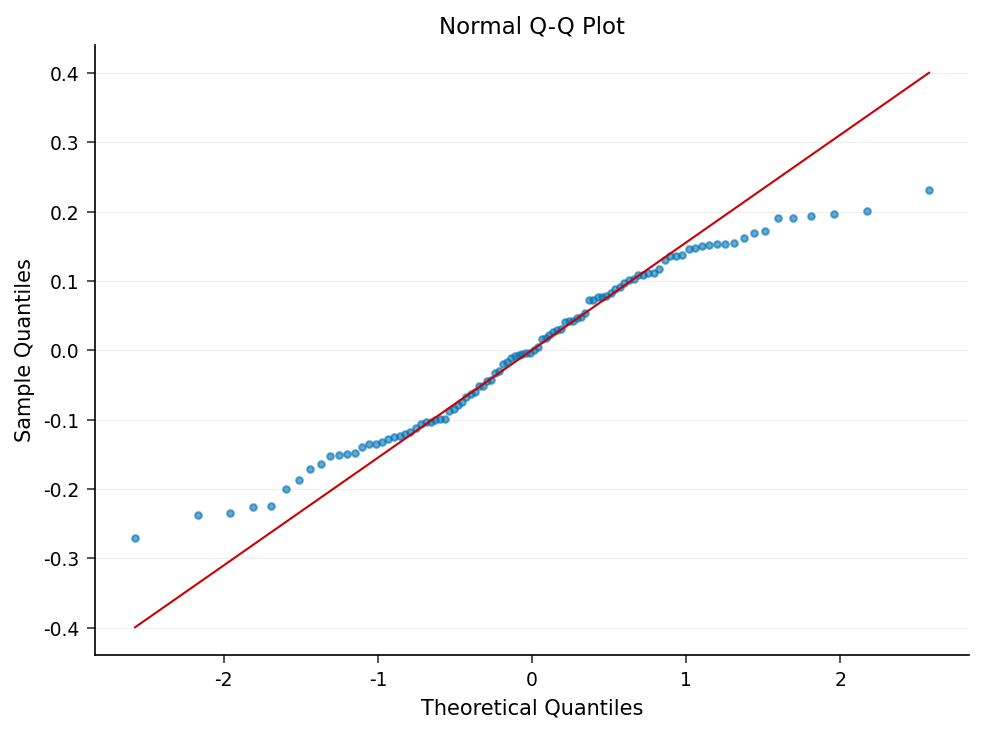

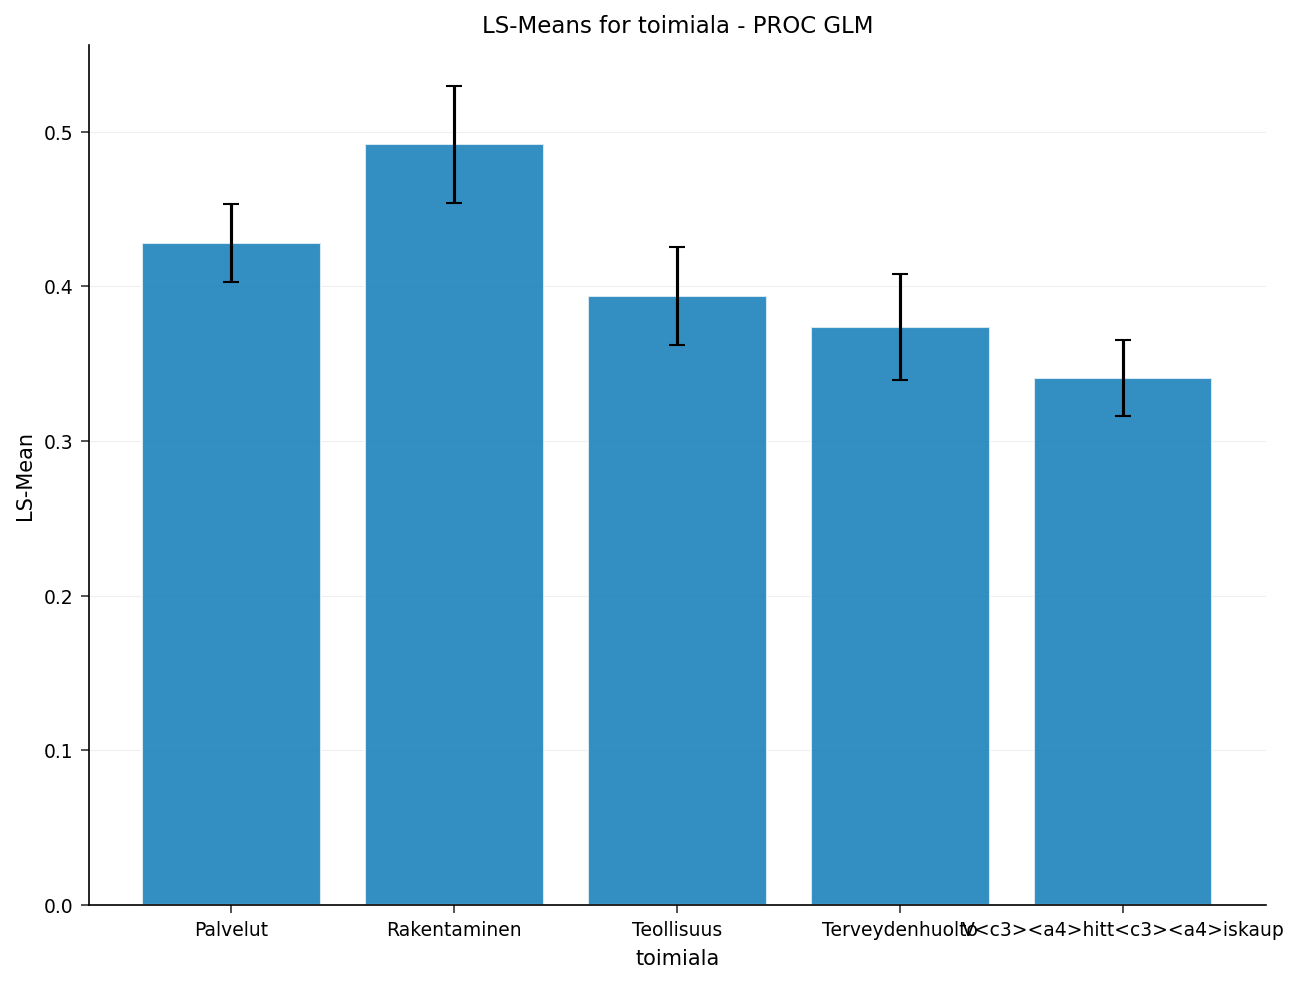

In [4]:
/* Käyttöaste toimialasegmentin mukaan, ajurit vakioiden */
PROSEDUURI GLM TIEDOT=luottolimiitit;
    LUOKKA toimiala;
    MODEL kayttoaste =
          toimiala velanhoitokate liikevaihdon_volatiliteetti aiempi_kayttoaste
          tyottomyysaste lyhyt_korko
          / SOLUTION ss3;
    LSMEANS toimiala / PDIFF ADJUST=TUKEY cl;
SUORITA;
QUIT;

## 5. Käyttöastevyöhyke stressiä ja taloudellista pääomaa varten

Pääomasuunnittelu tarvitsee käyttöastejakauman **hännät**, ei vain keskiarvon. Koska murtoluvulliset persentiilit otetaan parhaiten **PROC UNIVARIATE** -proseduurista eikä PROC MEANS -proseduurista, käytämme `PCTLPTS=`-optiota poimimaan käyttöasteen **2,5. ja 97,5. persentiilit**. Tuloksena syntyvä vyöhyke määrittää uskottavan matalan/korkean noston skenaarion rahoitetun saldon stressitestausta varten.


In [5]:
/* Käyttöasteen 2,5. / 97,5. persentiilit stressivyöhykettä varten */
PROSEDUURI UNIVARIATE TIEDOT=luottolimiitit NOPRINT;
    MUUTTUJA kayttoaste;
    TULOSTE out=kayttoaste_vyohyke
           mean=kayttoaste_keskiarvo
           pctlpts=2.5 97.5
           pctlpre=kayttoaste_p
           pctlname=lo hi;
SUORITA;

PROSEDUURI TULOSTA TIEDOT=kayttoaste_vyohyke noobs NIMIKE;
    NIMIKE kayttoaste_keskiarvo = "Käyttöasteen keskiarvo"
          kayttoaste_plo  = "2,5. persentiili (matala stressi)"
          kayttoaste_phi  = "97,5. persentiili (korkea stressi)";
SUORITA;


  Käyttöasteen keskiarvo  2,5. persentiili (matala stressi)  97,5. persentiili (korkea stressi)
------------------------  ---------------------------------  ----------------------------------
                0.396538                             0.1212                              0.7438




NOTE: PROC UNIVARIATE
NOTE: Output dataset kayttoaste_vyohyke has 1 observations and 3 variables.
NOTE: PROC PRINT data=kayttoaste_vyohyke

NOTE: PROC PRINT completed: 1 observations printed, 3 variables


## 6. Tulkinta ja jatkotoimet

**Mitä malli osoittaa**

- **Riskiluokka ohjaa rahoitettua vastuuta.** PROC MEANS -profiili osoittaa keskimääräisen käyttöasteen nousevan monotonisesti vahvimmasta luokasta heikoimpaan — 0,307 (A), 0,359 (B), 0,416 (C), 0,488 (D), 0,518 (E). Koska nostettu saldo on käyttöaste kertaa sitova limiitti, heikommat luokat muuntavat suuremman osan sitoumuksistaan rahoitetuiksi saldoiksi — keskeinen syöte maksukyvyttömyystilanteen vastuulle ja taloudelliselle pääomalle uusiutuvissa limiiteissä. (Keskimääräinen nostettu saldo myös nousee luokan mukana, huipentuen luokassa D tässä 100 limiitin otoksessa; pieni 9 limiitin luokan E solu sisältää yhden erittäin suuren limiitin, joka kääntää sen sitovan limiitin keskiarvoa — juuri sellaista pienten solujen käyttäytymistä, jonka täysi kanta tasoittaisi pois.)
- **Lainanottajan perustekijät hallitsevat regressiota.** PROC REG:ssä **velanhoitokate** kantaa suurimman standardoidun kertoimen (-0,45) ja on suojaava — jokainen lisäyksikkö katetta laskee käyttöastetta noin 0,11:llä (95 %:n LR -0,152–-0,075). **Aiempi käyttöaste** on seuraavaksi vahvin ajuri (standardoitu 0,41, estimaatti +0,38): aiemmin runsaasti nostetut limiitit pysyvät korkeasti käytettyinä. **Liikevaihdon volatiliteetti** (+0,37, p = 0,021) ja makrotermit — **työttömyys** (+0,036, p = 0,009) ja **lyhyt korko** (+0,036, p = 0,036) — ovat kaikki positiivisia ja merkitseviä, joten laskusuhdanne nostaa mekaanisesti koko portfolion rahoitettuja saldoja. Kaikki VIF-arvot ovat alle 1,17, selvästi tavanomaisen 10:n kynnyksen alapuolella, mikä vahvistaa etteivät ajurit ole kollineaarisia, ja CLB-välit sulkevat nollan pois jokaisen efektin osalta paitsi limiitin iän. Residuaalidiagnostiikka on hyväkäytöksistä: residuaalit hajaantuvat satunnaisesti nollan ympärille, histogrammi on suunnilleen normaali ja Q-Q-kuvaaja on lähes lineaarinen vain lievällä hännän poikkeamalla; Cookin D merkitsee neljä kohtalaisen vaikutusvaltaista limiittiä (yli 4/n = 0,04), joita kannattaa tarkastella tietojen laadun kannalta.
- **Toimiala lisää rajatapauksellisen jäännössignaalin.** Kun lainanottajan ja makrokovariaatit on vakioitu, kokonaistoimialavaikutus PROC GLM:ssä on vain rajatapaus (tyypin III F p = 0,060). Silti Tukey-korjatut pienimmän neliösumman keskiarvot erottavat segmentit: **rakentamisella** on korkein korjattu käyttöaste (0,492), sitä seuraa **palvelut** (0,428), kun taas **valmistus** (0,394), **terveydenhuolto** (0,374) ja **vähittäiskauppa** (0,366) ryhmittyvät alle. Pareittaiset testit vahvistavat, että rakentaminen nostaa merkitsevästi enemmän kuin **vähittäiskauppa** (ero 0,126, p = 0,007) ja **terveydenhuolto** (0,118, p = 0,024); loput pareittaiset erot eivät ole merkitseviä. Tämä on yhdenmukaista sen kanssa, miten käyttöpääoman intensiteetti vaihtelee sektoreittain, ja nostaa rakentamisen tarkkailtavaksi segmentiksi.

**Miten sitä käytetään**

- **Ennusta rahoitettuja saldoja** soveltamalla regressiota eteenpäin katsoviin makropolkuihin (nouseva työttömyys, korkeammat lyhyet korot) portfolion nostetun saldon projisoimiseksi kussakin skenaariossa.
- **Aseta taloudellisen pääoman stressivyöhyke** PROC UNIVARIATE -persentiileistä: käyttöaste vaihtelee uskottavasti **0,121**:stä (2,5.) **0,744**:ään (97,5.) noin 0,404:n keskiarvon ympärillä, mitoittaen matalan/korkean noston skenaarion laskusuhdannetta varten.
- **Eriytä limiitit ja hinnoittelu** riskiluokan ja rakentamisen kohonneen korjatun noston mukaan, veloittaen korkeammasta odotetusta käyttöasteesta — ja korkeammasta rahoitetusta vastuusta — jonka MEANS- ja GLM-tulokset kvantifioivat.

**Laajennukset**

Korvaa OLS-linkki murto-osavaste- tai beta-regressiolla (PROC GLIMMIX / PROC NLMIXED) kunnioittaaksesi 0–1-rajaa, lisää lainanottajan satunnaisefekti moni jaksoisia paneeleja varten ja syötä sovitettu käyttöaste suoraan tappio-maksukyvyttömyys- ja taloudellisen pääoman moottoriin. Uudelleenajo täydellä (rajoittamattomalla) kannalla tiivistäisi pienet riskiluokka- ja toimialasolut ja todennäköisesti terävöittäisi rajatapauksellisen toimialan F-testin.
